# ML & Forecasting voor Recommender Systems (MongoDB)

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pymongo import MongoClient

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

## 2. Connection to MongoDB

In [15]:
load_dotenv()

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB")
MONGODB_COLLECTION_RATINGS = os.getenv("MONGODB_COLLECTION_RATINGS", "reviews") # Of 'interactions'
MONGODB_COLLECTION_APPS = os.getenv("MONGODB_COLLECTION_APPS", "steam_apps")     # Voor game namen

if not MONGODB_URI or not MONGODB_DB:
    raise ValueError("Zet MONGODB_URI en MONGODB_DB in je .env bestand.")

client = MongoClient(MONGODB_URI)
db = client[MONGODB_DB]

## 3. Data ophalen uit MongoDB

In [16]:
print("Data ophalen uit MongoDB...")

# A. Ratings/Interactions ophalen
ratings_cursor = db[MONGODB_COLLECTION_RATINGS].find({})
ratings = pd.DataFrame(list(ratings_cursor))

# Kolomnamen standaardiseren
ratings = ratings.rename(columns={
    "SteamId": "user_id",
    "AppId": "app_id",
    "PlaytimeForever": "playtime_forever",
    "CreatedUtc": "review_date",
})

# B. Game metadata ophalen (voor leesbare aanbevelingen)
print("Game metadata ophalen...")
apps_cursor = db[MONGODB_COLLECTION_APPS].find({}, {"AppId": 1, "Name": 1, "_id": 0})
apps_df = pd.DataFrame(list(apps_cursor))
# Maak een lookup dictionary: ID -> Naam
id_to_name = {}
if not apps_df.empty:
    id_to_name = apps_df.set_index("AppId")["Name"].to_dict()

# C. Validatie van data
required_fields = {"user_id", "app_id"}
if not required_fields.issubset(set(ratings.columns)):
    raise ValueError(f"Verplichte velden ontbreken: {required_fields - set(ratings.columns)}")

# Impliciete feedback omzetten naar rating (Log transformatie voor playtime)
if "rating" not in ratings.columns:
    if "playtime_forever" in ratings.columns:
        # log1p zorgt dat 0 blijft 0, en vlakt extreme uitschieters af
        ratings["rating"] = np.log1p(ratings["playtime_forever"])
    else:
        raise ValueError("Geen 'rating' of 'playtime_forever' gevonden.")

print(f"Dataset ingeladen: {ratings.shape[0]} rijen.")
print(ratings.head())

Data ophalen uit MongoDB...
Game metadata ophalen...
Dataset ingeladen: 2257 rijen.
                        _id            user_id  app_id  playtime_forever  \
0  000000000000000000000000  76561198164987397     220             182.0   
1  69430a9999ef83246483b402  76561198080219056     220             793.0   
2  69430a9999ef83246483b403  76561198080219056     400             208.0   
3  69430a9999ef83246483b404  76561198080219056     550            1102.0   
4  69430a9999ef83246483b405  76561198080219056     620            1465.0   

   Playtime2Weeks             review_date              UpdatedUtc    rating  
0             0.0 2025-12-17 19:42:36.009 2025-12-28 20:15:23.859  5.209486  
1             0.0                     NaT 2025-12-17 19:55:04.152  6.677083  
2             0.0                     NaT 2025-12-17 19:55:04.152  5.342334  
3             0.0                     NaT 2025-12-17 19:55:04.152  7.005789  
4             0.0                     NaT 2025-12-17 19:55:04.152  7.

In [4]:
# (Optioneel) Games metadata ophalen zodat je app_id -> titel kan tonen
games_cursor = db[MONGODB_COLLECTION_GAMES].find({})
games = pd.DataFrame(list(games_cursor))

app_col = next((c for c in ['AppId','app_id','appid'] if c in games.columns), None)
name_col = next((c for c in ['Name','Title','name','title'] if c in games.columns), None)

id_to_name = {}
if app_col and name_col:
    id_to_name = dict(zip(games[app_col], games[name_col]))
    print(f"Games geladen: {len(id_to_name)} titels")
else:
    print("Geen herkenbare kolommen gevonden voor app_id/titel in games-collectie.")
    print("Beschikbare kolommen:", games.columns.tolist())


Games geladen: 150405 titels


## 4. Exploratory Data Analysis (EDA)


--- EDA ---
            rating  playtime_forever
count  2257.000000       2257.000000
mean      5.911816       2704.994240
std       1.984076      13468.944628
min       0.693147          1.000000
25%       4.553877         94.000000
50%       5.902633        365.000000
75%       7.207119       1348.000000
max      12.984808     435742.000000


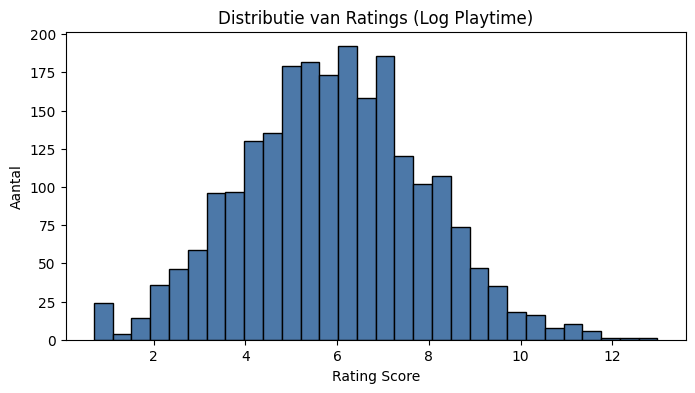

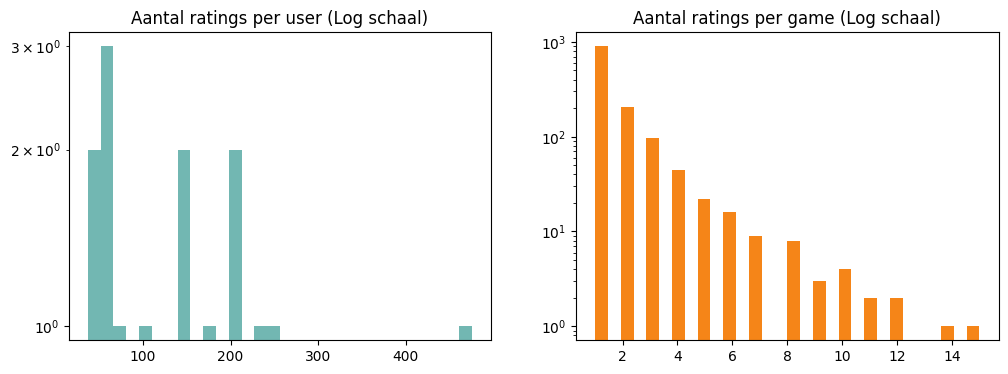

In [17]:
print("\n--- EDA ---")
print(ratings[["rating", "playtime_forever"]].describe())

# Visualisatie 1: Rating distributie
plt.figure(figsize=(8, 4))
plt.hist(ratings["rating"], bins=30, color="#4C78A8", edgecolor='black')
plt.title("Distributie van Ratings (Log Playtime)")
plt.xlabel("Rating Score")
plt.ylabel("Aantal")
plt.show()

# Visualisatie 2: Long-tail check
user_counts = ratings["user_id"].value_counts()
item_counts = ratings["app_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_counts, bins=30, log=True, color="#72B7B2")
axes[0].set_title("Aantal ratings per user (Log schaal)")
axes[1].hist(item_counts, bins=30, log=True, color="#F58518")
axes[1].set_title("Aantal ratings per game (Log schaal)")
plt.show()

## 5. Preprocessing & filtering

In [18]:
MIN_USER_RATINGS = 5
MIN_ITEM_RATINGS = 5

print(f"Filtering: Minimaal {MIN_USER_RATINGS} ratings per user, {MIN_ITEM_RATINGS} per item.")
filtered = ratings.copy()
filtered = filtered[filtered["user_id"].map(user_counts) >= MIN_USER_RATINGS]
filtered = filtered[filtered["app_id"].map(item_counts) >= MIN_ITEM_RATINGS]

print(f"Shape na filtering: {filtered.shape}")


Filtering: Minimaal 5 ratings per user, 5 per item.
Shape na filtering: (475, 8)


## 6. Train/test split (user-level)

In [19]:
def user_train_test_split(df, test_size=0.2, random_state=42, time_col="review_date"):
    """
    Splitst data per user. Als er tijdsdata is, gebruiken we de laatste X% interacties
    als testdata (realistisch scenario). Anders random split.
    """
    train_rows = []
    test_rows = []
    has_time = time_col in df.columns

    for user_id, group in df.groupby("user_id"):
        # Te weinig data om te splitsen? Alles naar train.
        if len(group) < 2:
            train_rows.append(group)
            continue

        if has_time:
            g = group.copy()
            g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
            g = g.sort_values(time_col)
            
            valid_dates = g[time_col].notna().sum()
            if valid_dates >= 2:
                split_idx = max(1, int(len(g) * (1 - test_size)))
                train_rows.append(g.iloc[:split_idx])
                test_rows.append(g.iloc[split_idx:])
                continue

        # Fallback: Random split
        train, test = train_test_split(group, test_size=test_size, random_state=random_state)
        train_rows.append(train)
        test_rows.append(test)

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True) if test_rows else df.iloc[0:0]
    return train_df, test_df

train_df, test_df = user_train_test_split(filtered, test_size=0.2)
print(f"Train set: {train_df.shape}, Test set: {test_df.shape}")

Train set: (374, 8), Test set: (101, 8)


In [20]:
# Pivot table: Rijen=Items, Kolommen=Users
# Let op: Bij miljoenen rijen is scipy.sparse.csr_matrix beter, maar voor deze schaal is pivot prima.
item_user_matrix = train_df.pivot_table(
    index="app_id", columns="user_id", values="rating", fill_value=0
)

print("KNN Model fitten...")
model_knn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
model_knn.fit(item_user_matrix)

KNN Model fitten...


NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1)

## 7. Recommender: Item-based Collaborative Filtering (cosine)

In [21]:
def recommend_items(user_id, knn_model, matrix, train_data, top_k=5, seed_k=3, neighbor_k=20):
    if user_id not in matrix.columns:
        return [] # Cold start user

    # 1. Haal items op die de user al heeft (Seed items)
    user_history = train_data[train_data["user_id"] == user_id]
    
    # Sorteer op rating (hoogste eerst) en pak de top seed_k
    seeds = user_history.sort_values("rating", ascending=False).head(seed_k)["app_id"].tolist()
    owned_items = set(user_history["app_id"].tolist())

    scores = {}

    # 2. Zoek buren voor elk seed item
    for item_id in seeds:
        if item_id not in matrix.index:
            continue
        
        # Zoek nearest neighbors van dit item
        item_vec = matrix.loc[[item_id]]
        distances, indices = knn_model.kneighbors(item_vec, n_neighbors=neighbor_k)
        
        # 3. Score aggregatie
        for dist, idx in zip(distances.flatten(), indices.flatten()):
            neighbor_id = matrix.index[idx]
            
            # Sla over als user het al heeft of als het het item zelf is
            if neighbor_id in owned_items or neighbor_id == item_id:
                continue
            
            # Similarity score (1 - cosine distance)
            similarity = 1.0 - dist
            scores[neighbor_id] = scores.get(neighbor_id, 0) + similarity

    # 4. Sorteren en top-k teruggeven
    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in ranked_items[:top_k]]

# Helper voor pretty printen
def _pretty(item_ids):
    return [f"{i}: {id_to_name.get(i, 'Unknown')}" for i in item_ids]

# Testje met een user
sample_user = train_df["user_id"].iloc[0]
recs = recommend_items(sample_user, model_knn, item_user_matrix, train_df, top_k=5)
print(f"\nVoorbeeld aanbevelingen voor user {sample_user}:")
print(_pretty(recs))


Voorbeeld aanbevelingen voor user 76561198021592344:
['730: Counter-Strike 2', '1172470: Apex Legends™', '823130: Totally Accurate Battlegrounds', '202990: Unknown', '212910: Unknown']


In [9]:
debug_users = train_df['user_id'].drop_duplicates().head(3).tolist()
neighbor_grid = [5, 10, 20, 40]

def _pretty(items):
    # show both id and title if available
    out = []
    for a in items:
        title = id_to_name.get(a) if 'id_to_name' in globals() else None
        out.append(f"{a} ({title})" if title else str(a))
    return out

for u in debug_users:
    print(f"\nUser {u}")
    recs_by_n = {}
    for n in neighbor_grid:
        tmp = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=n)
        tmp.fit(item_user_matrix)
        recs = recommend_items(u, tmp, item_user_matrix, train_df, top_k=5, seed_k=3, neighbor_k=n)
        recs_by_n[n] = recs
        print(f"  n={n}: {_pretty(recs)}")

    # show overlap between smallest and largest
    a, b = set(recs_by_n[neighbor_grid[0]]), set(recs_by_n[neighbor_grid[-1]])
    jacc = len(a & b) / len(a | b) if (a | b) else 0
    print(f"  Jaccard(top-5 {neighbor_grid[0]} vs {neighbor_grid[-1]}) = {jacc:.2f}")


User 76561198021592344
  n=5: ['730 (Counter-Strike 2)']
  n=10: ['730 (Counter-Strike 2)', '202990', '212910', '238960 (Path of Exile)', '304050 (Trove)']
  n=20: ['730 (Counter-Strike 2)', '1172470 (Apex Legends™)', '823130 (Totally Accurate Battlegrounds)', '202990', '212910']
  n=40: ['730 (Counter-Strike 2)', '823130 (Totally Accurate Battlegrounds)', '238960 (Path of Exile)', '252490 (Rust)', '105600 (Terraria)']
  Jaccard(top-5 5 vs 40) = 0.20

User 76561198031182634
  n=5: ['238960 (Path of Exile)', '252490 (Rust)', '301520', '1172470 (Apex Legends™)', '1085660 (Destiny 2)']
  n=10: ['252490 (Rust)', '1172470 (Apex Legends™)', '238960 (Path of Exile)', '301520', '440 (Team Fortress 2)']
  n=20: ['238960 (Path of Exile)', '252490 (Rust)', '301520', '1172470 (Apex Legends™)', '386360 (SMITE®)']
  n=40: ['238960 (Path of Exile)', '301520', '1172470 (Apex Legends™)', '1085660 (Destiny 2)', '431960']
  Jaccard(top-5 5 vs 40) = 0.67

User 76561198057027099
  n=5: ['570 (Dota 2)', '1

## 8. Evaluatie: Precision en Recall

In [22]:
def evaluate_model(knn_model, matrix, train_data, test_data, k=5, seed_k=3, neighbor_k=20):
    hits = 0
    total_relevant = 0
    total_recommended = 0
    
    # Evalueer alleen users die in de test set zitten
    test_users = test_data["user_id"].unique()
    
    for u in test_users:
        # Ground truth: wat heeft de user in de test set gedaan?
        true_items = set(test_data[test_data["user_id"] == u]["app_id"])
        if not true_items: continue
            
        # Voorspelling
        recs = recommend_items(u, knn_model, matrix, train_data, top_k=k, seed_k=seed_k, neighbor_k=neighbor_k)
        
        # Berekening
        intersection = len(true_items & set(recs))
        hits += intersection
        total_relevant += len(true_items)
        total_recommended += len(recs)
        
    precision = hits / total_recommended if total_recommended > 0 else 0
    recall = hits / total_relevant if total_relevant > 0 else 0
    return precision, recall

print("\n--- Evaluatie Start ---")
prec, rec = evaluate_model(model_knn, item_user_matrix, train_df, test_df)
print(f"Model Performance (k=5): Precision={prec:.4f}, Recall={rec:.4f}")


--- Evaluatie Start ---
Model Performance (k=5): Precision=0.2000, Recall=0.1485


In [11]:
# Baseline evaluatie (huidig model)
precision, recall = precision_recall_at_k(model, train_df, test_df, item_user_matrix, k=5, seed_k=3, neighbor_k=20)
print("Item-KNN Precision:", precision)
print("Item-KNN Recall:", recall)

# Popularity baseline (meest voorkomende items in train)
top_popular = train_df["app_id"].value_counts().index.tolist()

def recommend_popular(user_id, top_k=5):
    owned = set(train_df.loc[train_df['user_id']==user_id, 'app_id'].tolist())
    recs = [a for a in top_popular if a not in owned]
    return recs[:top_k]

def precision_recall_popular(test_df, k=5):
    hit=0; tot_rel=0; tot_rec=0
    for user_id, group in test_df.groupby('user_id'):
        true_items=set(group['app_id'].tolist())
        recs=recommend_popular(user_id, top_k=k)
        hit += len(true_items & set(recs))
        tot_rel += len(true_items)
        tot_rec += len(recs)
    return (hit/tot_rec if tot_rec else 0, hit/tot_rel if tot_rel else 0)

p_pop, r_pop = precision_recall_popular(test_df, k=5)
print("Popularity Precision:", p_pop)
print("Popularity Recall:", r_pop)


Item-KNN Precision: 0.2
Item-KNN Recall: 0.1485148514851485
Popularity Precision: 0.30666666666666664
Popularity Recall: 0.22772277227722773


## 9. Hyperparameter optimalisatie


--- Hyperparameter Tuning ---
   n_neighbors  precision    recall
2           50   0.266667  0.198020
1           20   0.200000  0.148515
0           10   0.206349  0.128713


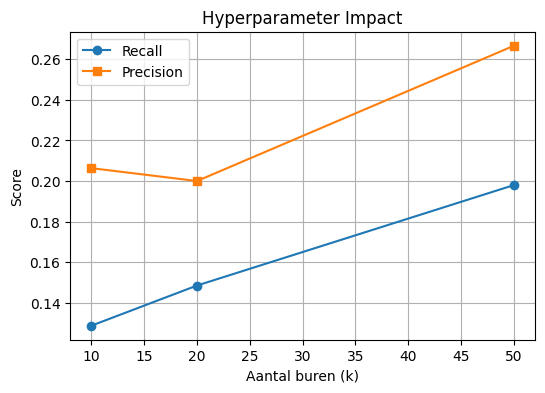

In [23]:
print("\n--- Hyperparameter Tuning ---")
neighbor_grid = [10, 20, 50]
results = []

for n in neighbor_grid:
    # Train nieuw model met n neighbors
    tmp_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=n, n_jobs=-1)
    tmp_model.fit(item_user_matrix)
    
    p, r = evaluate_model(tmp_model, item_user_matrix, train_df, test_df, neighbor_k=n)
    results.append({"n_neighbors": n, "precision": p, "recall": r})

results_df = pd.DataFrame(results)
print(results_df.sort_values("recall", ascending=False))

# Plot resultaten
plt.figure(figsize=(6, 4))
plt.plot(results_df["n_neighbors"], results_df["recall"], marker='o', label="Recall")
plt.plot(results_df["n_neighbors"], results_df["precision"], marker='s', label="Precision")
plt.xlabel("Aantal buren (k)")
plt.ylabel("Score")
plt.title("Hyperparameter Impact")
plt.legend()
plt.grid(True)
plt.show()

## 10. Forecasting: seizoensgebonden trends

In [ ]:
print("\n--- Forecasting Analysis ---")

if "review_date" in ratings.columns:
    ratings["review_date"] = pd.to_datetime(ratings["review_date"], errors="coerce")
    
    # Aggregeren per maand ('ME' is Month End in pandas > 2.2, anders 'M')
    try:
        monthly = ratings.set_index("review_date").resample("ME").size().reset_index(name="count")
    except ValueError:
        monthly = ratings.set_index("review_date").resample("M").size().reset_index(name="count")

    if len(monthly) > 6:
        # Feature Engineering: Tijdindex + Sin/Cos voor Seizoensgebondenheid
        monthly["time_idx"] = np.arange(len(monthly))
        monthly["month_num"] = monthly["review_date"].dt.month
        monthly["sin_month"] = np.sin(2 * np.pi * monthly["month_num"] / 12)
        monthly["cos_month"] = np.cos(2 * np.pi * monthly["month_num"] / 12)

        # Train/Test split voor forecasting (Laatste 3 maanden is test)
        split = len(monthly) - 1
        train_ts = monthly.iloc[:split]
        test_ts = monthly.iloc[split:]

        X_cols = ["time_idx", "sin_month", "cos_month"]
        reg = LinearRegression()
        reg.fit(train_ts[X_cols], train_ts["count"])

        # Voorspellen
        preds = reg.predict(test_ts[X_cols])
        
        # Evaluatie
        mae = mean_absolute_error(test_ts["count"], preds)
        rmse = np.sqrt(mean_squared_error(test_ts["count"], preds)) # Safe syntax for RMSE

        # Trend Analyse
        trend_coef = reg.coef_[0] # Coefficient van time_idx
        trend_status = "GROEIEND" if trend_coef > 0 else "DALEND"

        print(f"Forecast MAE: {mae:.2f}, RMSE: {rmse:.2f}")
        print(f"Platform Trend: {trend_status} (Slope: {trend_coef:.2f})")
        print("Advies: " + ("Focus op 'Trending Now' secties." if trend_coef > 0 else "Focus op retention / 'Classics'."))

        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(monthly["review_date"], monthly["count"], label="Actual Data", marker='.')
        plt.plot(test_ts["review_date"], preds, label="Forecast (Regression)", linestyle="--", color='red')
        plt.title(f"Activity Forecast (Trend: {trend_status})")
        plt.legend()
        plt.show()
    else:
        print("Te weinig data voor zinvolle forecasting.")
else:
    print("Geen datum kolom beschikbaar voor forecasting.")


--- Forecasting Analysis ---
Te weinig data voor zinvolle forecasting.
